In [1]:
# Importação das bibliotecas principais
import pandas as pd
import numpy as np

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [2]:
# Carregando o dataset de exemplo
df = pd.read_csv('funcionarios_empresa.csv')

In [3]:
print(df.head())

   ID_Funcionario                Nome  Idade Departamento  \
0               1  Tatiane Mendes 001     40       Vendas   
1               2       Ana Silva 002     23    Marketing   
2               3    Rafael Alves 003     36           TI   
3               4     Carla Souza 004     32    Operações   
4               5     Pedro Costa 005     33   Financeiro   

                      Cargo  Salario  Tempo_Empresa_Meses Data_Admissao  \
0               Vendedor Jr  3685.36                    4    2025-05-18   
1  Coordenador de Marketing  8081.03                    1    2025-08-16   
2       Desenvolvedor Pleno  8491.98                    2    2025-07-17   
3      Gerente de Operações  9745.30                    9    2024-12-19   
4    Analista Financeiro Jr  3556.68                   63    2020-07-13   

      Nivel_Educacao Estado_Civil Tipo_Contrato  Avaliacao_Performance  \
0  Superior Completo    Casado(a)           CLT                    4.8   
1  Superior Completo  Solteiro(a) 

In [4]:
print("\n" + "="*50)
print("Informações gerais do dataset:")
print(df.info())

print("\n" + "="*50)
print("Dimensões do dataset:")
print(f"Linhas: {df.shape[0]}, Colunas: {df.shape[1]}")


Informações gerais do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID_Funcionario         500 non-null    int64  
 1   Nome                   500 non-null    object 
 2   Idade                  500 non-null    int64  
 3   Departamento           500 non-null    object 
 4   Cargo                  500 non-null    object 
 5   Salario                500 non-null    float64
 6   Tempo_Empresa_Meses    500 non-null    int64  
 7   Data_Admissao          500 non-null    object 
 8   Nivel_Educacao         495 non-null    object 
 9   Estado_Civil           500 non-null    object 
 10  Tipo_Contrato          500 non-null    object 
 11  Avaliacao_Performance  475 non-null    float64
 12  Horas_Extras_Mes       500 non-null    int64  
 13  Beneficios             490 non-null    float64
 14  Faltas_Ultimo_Ano      500

In [5]:
print(df.describe())

       ID_Funcionario       Idade       Salario  Tempo_Empresa_Meses  \
count      500.000000  500.000000    500.000000            500.00000   
mean       250.500000   35.764000   7780.120720             21.79600   
std        144.481833    9.610673   4108.494711             22.63234   
min          1.000000   19.000000   1170.990000              1.00000   
25%        125.750000   29.000000   4446.787500              5.00000   
50%        250.500000   35.000000   7167.265000             14.00000   
75%        375.250000   41.000000   9846.422500             30.00000   
max        500.000000   67.000000  37988.030000            120.00000   

       Avaliacao_Performance  Horas_Extras_Mes   Beneficios  \
count             475.000000        500.000000   490.000000   
mean                3.427368         10.370000   811.200224   
std                 0.765589         11.298159   210.466584   
min                 1.000000          0.000000   149.100000   
25%                 2.900000        

In [6]:
# Soma de valores nulos
print(df.isnull().sum())

ID_Funcionario            0
Nome                      0
Idade                     0
Departamento              0
Cargo                     0
Salario                   0
Tempo_Empresa_Meses       0
Data_Admissao             0
Nivel_Educacao            5
Estado_Civil              0
Tipo_Contrato             0
Avaliacao_Performance    25
Horas_Extras_Mes          0
Beneficios               10
Faltas_Ultimo_Ano         0
Satisfacao_Trabalho      15
dtype: int64


In [8]:
print("Tratamento de valores nulos!!!")
# Nivel_Educacao - categórica - moda
print(df['Nivel_Educacao'].fillna(df['Nivel_Educacao'].mode()[0], inplace=True))

# Avaliacao_Performance - numérica - mediana
print(df['Avaliacao_Performance'].fillna(df['Avaliacao_Performance'].median(), inplace=True))

# Beneficios - numérica - mediana
print(df['Beneficios'].fillna(df['Beneficios'].median(), inplace=True))

# Satisfacao_Trabalho - numérica - mediana
print(df['Satisfacao_Trabalho'].fillna(df['Satisfacao_Trabalho'].median(), inplace=True))

print(df.isnull().sum())

Tratamento de valores nulos!!!
None
None
None
None
ID_Funcionario           0
Nome                     0
Idade                    0
Departamento             0
Cargo                    0
Salario                  0
Tempo_Empresa_Meses      0
Data_Admissao            0
Nivel_Educacao           0
Estado_Civil             0
Tipo_Contrato            0
Avaliacao_Performance    0
Horas_Extras_Mes         0
Beneficios               0
Faltas_Ultimo_Ano        0
Satisfacao_Trabalho      0
dtype: int64


/tmp/ipython-input-704857741.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  print(df['Avaliacao_Performance'].fillna(df['Avaliacao_Performance'].median(), inplace=True))
/tmp/ipython-input-704857741.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'd

In [10]:
# Detecção de outliers usando o metodo de IQR.

# Selecionar somente colunas numéricas
numeric_df = df.select_dtypes(include='number')

# Cálculo do IQR
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# Limites inferior e superior
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Máscara de outliers
outliers_mask = (numeric_df < lower_bound) | (numeric_df > upper_bound)

# Quantidade de outliers por coluna
print("Quantidade de outliers por coluna:")
print(outliers_mask.sum())

outliers_df = df[outliers_mask.any(axis=1)]

print("\nLinhas que contêm outliers:")
print(outliers_df)


Quantidade de outliers por coluna:
ID_Funcionario            0
Idade                    20
Salario                   5
Tempo_Empresa_Meses      28
Avaliacao_Performance     8
Horas_Extras_Mes         23
Beneficios                4
Faltas_Ultimo_Ano         2
Satisfacao_Trabalho       3
dtype: int64

Linhas que contêm outliers:
     ID_Funcionario                 Nome  Idade Departamento  \
5                 6   Vanessa Castro 006     28    Operações   
8                 9     Rafael Alves 009     37           TI   
11               12   Renata Freitas 012     32    Marketing   
20               21      Pedro Costa 021     28           TI   
33               34   Renata Freitas 034     27    Operações   
..              ...                  ...    ...          ...   
467             468      Pedro Costa 468     29   Financeiro   
468             469   Bruno Ferreira 469     24           RH   
472             473    Juliana Rocha 473     33    Marketing   
483             484  Larissa Ca

Muitas colunas possui valores fora do "normal", com isso irei usar a mediana para a substituição.

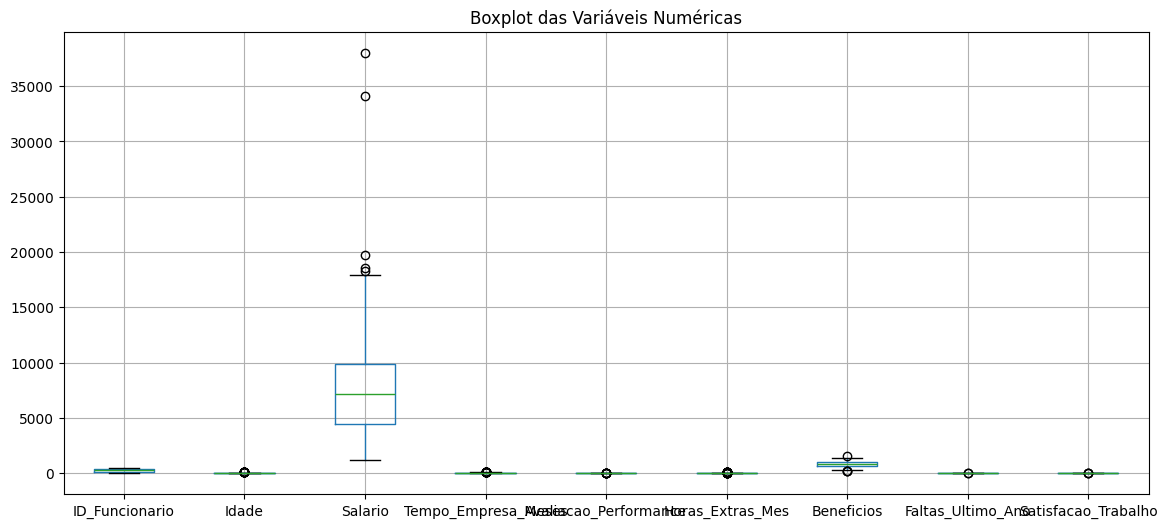

In [11]:
# Gráfico para visualizar esses outliers(boxplot)
import matplotlib.pyplot as plt

numeric_df.boxplot(figsize=(14,6))
plt.title("Boxplot das Variáveis Numéricas")
plt.show()


In [12]:
# Data set sem o tratamento de outliers
df_sem_tratamento_outliers = df.copy()

In [13]:
# Colunas que possui outliers
# Estou usando a mediana para tratar esses outliers.
colunas_numericas = ['Idade', 'Salario', 'Tempo_Empresa_Meses', 'Avaliacao_Performance',
                     'Horas_Extras_Mes', 'Beneficios', 'Faltas_Ultimo_Ano', 'Satisfacao_Trabalho']

for col in colunas_numericas:
    # Calculo Q1, Q3 e IQR
    Q1 = df_sem_tratamento_outliers[col].quantile(0.25)
    Q3 = df_sem_tratamento_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    # Limites inferior e superior
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Mediana da coluna
    mediana = df[col].median()

    # Substituição dos outliers pela mediana
    df[col] = df[col].apply(
        lambda x: mediana if x < limite_inferior or x > limite_superior else x
    )

print("Outliers tratados usando a mediana!")


Outliers tratados usando a mediana!


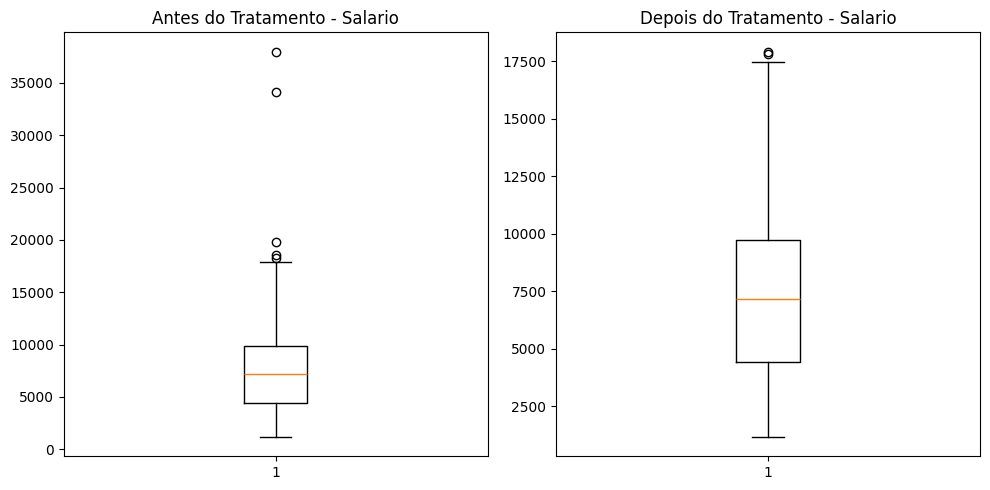

In [14]:
import matplotlib.pyplot as plt

col = "Salario"

plt.figure(figsize=(10,5))

# Antes
plt.subplot(1,2,1)
plt.boxplot(df_sem_tratamento_outliers[col].dropna())
plt.title(f"Antes do Tratamento - {col}")

# Depois
plt.subplot(1,2,2)
plt.boxplot(df[col].dropna())
plt.title(f"Depois do Tratamento - {col}")

plt.tight_layout()
plt.show()
